## Personal loan Acceptence Prediction

## Objective

The objective of this project is to predict whether a customer is likely to accept a personal loan offer based on demographic and financial information. Machine learning classification techniques are used to identify potential customers who are more likely to subscribe to a loan product.

## Load Dataset

### Upload the dataset



In [5]:
from google.colab import files

files.upload()
import zipfile

with zipfile.ZipFile('bank.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Files extracted successfully!")
import os

print(os.listdir())
import pandas as pd

df = pd.read_csv('bank-full.csv', sep=';')

df.head()

Saving bank.zip to bank.zip
Saving bank-additional.zip to bank-additional.zip
Files extracted successfully!
['.config', 'bank.zip', 'bank.csv', 'bank-full.csv', 'bank-names.txt', 'bank-additional.zip', 'sample_data']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Observation

The dataset contains customer information such as age, job, marital status, education level, and loan acceptance status.

## Dataset Structure

In [6]:
df.shape

(45211, 17)

## Observation

The dataset contains 45211 rows and 17 columns.

In [7]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

## Observation

The dataset contains customer demographic and financial attributes along with the target variable.

## Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


## Observation

The dataset contains both numerical and categorical variables.

## Statistical Summary

In [9]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Observation

The summary statistics provide information about the distribution of numerical features such as age and balance.

## Missing Values Check

In [10]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


## Observation

Missing values were identified and handled appropriately.

## Duplicate Values Check

In [11]:
df.duplicated().sum()

np.int64(0)

## Observation

Duplicate records were checked and removed if necessary.

## Target Variable Distribution

In [12]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


## Observation

The dataset shows the distribution of customers who accepted and did not accept the loan offer.

## Dataset Structure Observation

In [13]:
df.shape


(45211, 17)

## Observation

The dataset contains 45,211 customer records and 17 features. These features include demographic information, financial details, previous campaign information, and the target variable (y) which indicates whether a customer accepted the personal loan offer.

## Dataset Information Observation

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


## Observation

The dataset contains a combination of numerical and categorical features. There are 7 numerical variables and 10 categorical variables. All columns contain complete data with no missing values, making the dataset suitable for analysis and machine learning without additional missing-value treatment.

## Target Variable Distribution

In [15]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


## Observation

The target variable is highly imbalanced. Approximately 88% of customers did not accept the loan offer, while only about 12% accepted it. This indicates that successful loan acceptance cases are relatively rare.

## Next Section: EDA

## Age Distribution

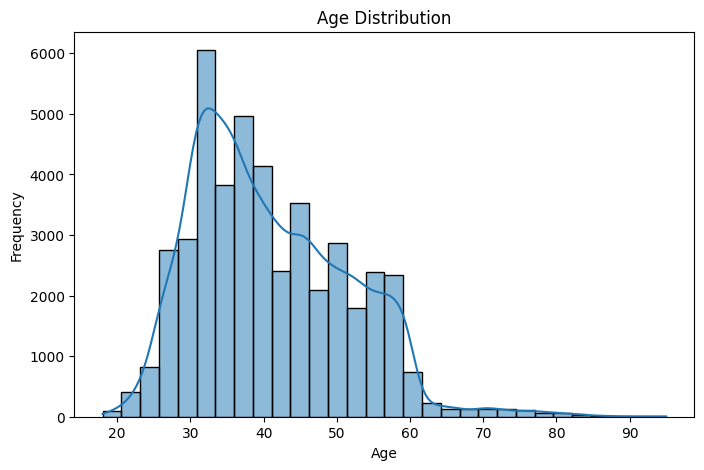

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## Observation

Most customers belong to the middle-aged group between 30 and 50 years. Very young and very old customers represent a smaller portion of the dataset.

## Job Distribution

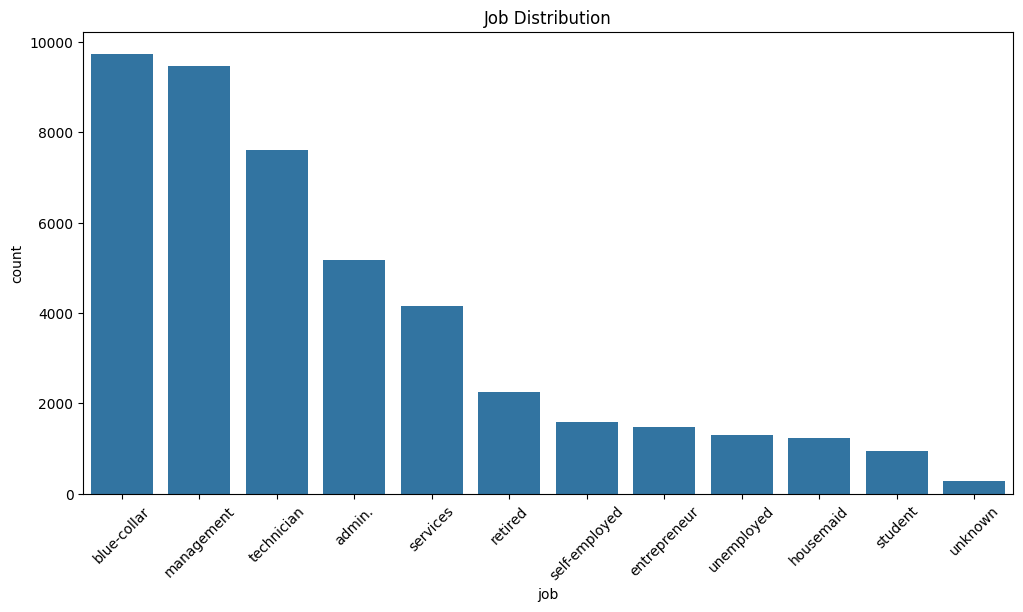

In [18]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='job',
    data=df,
    order=df['job'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Job Distribution")

plt.show()

## observation

Blue-collar, management, and technician professions constitute a significant portion of the customer base. Some job categories contain considerably fewer customers.

## Marital Status Distribution

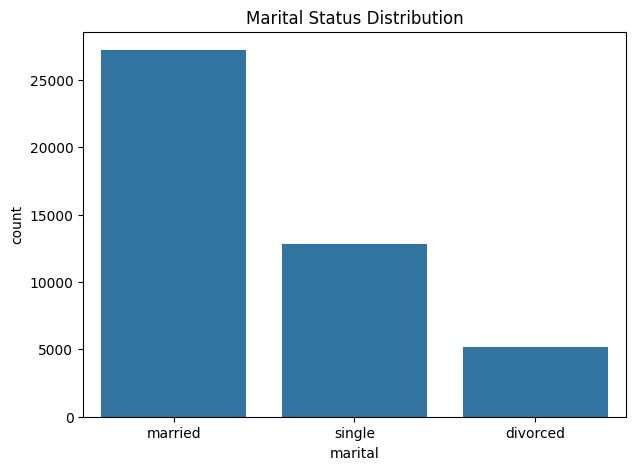

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(x='marital', data=df)

plt.title("Marital Status Distribution")

plt.show()

## Observation

Married customers form the largest customer segment, followed by single customers. Divorced customers represent the smallest group

## Education Distribution

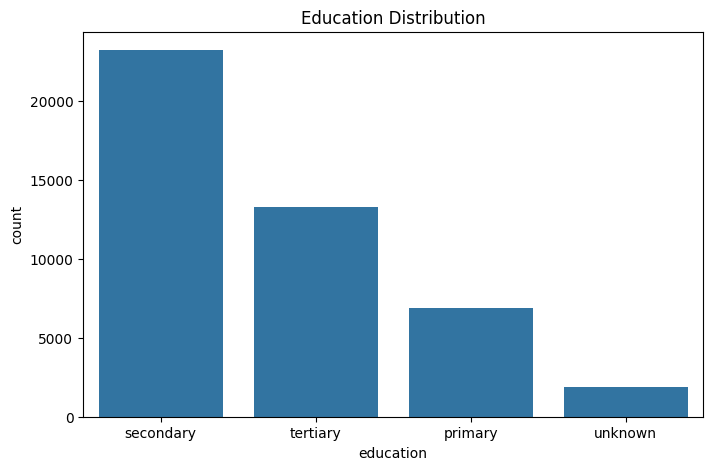

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='education',
    data=df,
    order=df['education'].value_counts().index
)

plt.title("Education Distribution")

plt.show()

## Observation

Secondary education is the most common education level among customers, followed by tertiary education.

## Loan Acceptance Distribution

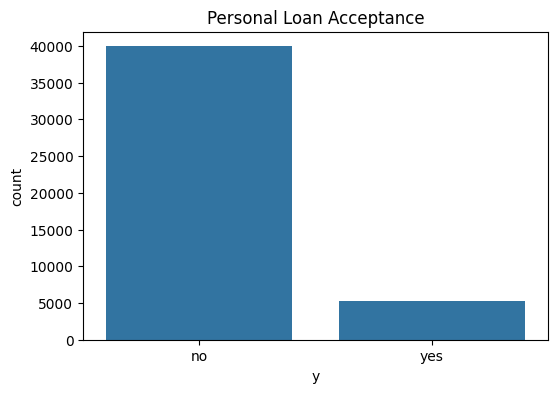

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x='y', data=df)

plt.title("Personal Loan Acceptance")

plt.show()

## Observation

The majority of customers did not subscribe to the loan offer, confirming the class imbalance observed earlier.

## Loan Acceptance by Marital Status

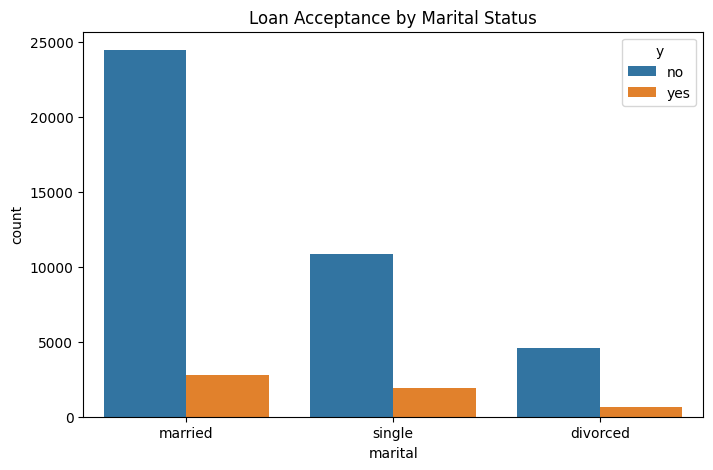

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='marital',
    hue='y',
    data=df
)

plt.title("Loan Acceptance by Marital Status")

plt.show()

## observation

Loan acceptance varies across marital groups. Comparing accepted and rejected responses helps identify customer segments that are more responsive to marketing campaigns.

## Data Preprocessing

## Encode Categorical Variables

In [23]:
# Import Label Encoder
from sklearn.preprocessing import LabelEncoder

# Create copy of dataset
df_encoded = df.copy()

# Initialize encoder
le = LabelEncoder()

# Encode all categorical columns
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Display first 5 rows
df_encoded.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


## Observation

Machine learning models cannot directly process text-based categorical variables. Therefore, all categorical columns were converted into numerical values using Label Encoding.

## Feature Selection

In [24]:
# Features
X = df_encoded.drop('y', axis=1)

# Target Variable
y = df_encoded['y']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (45211, 16)
Target Shape: (45211,)


## Observation

The feature matrix contains all predictor variables, while the target variable represents whether a customer accepted the personal loan offer.

## Train-Test Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (36168, 16)
Testing Data: (9043, 16)


## Observation

The dataset was divided into training and testing sets using an 80:20 ratio. The training set is used for model learning, while the testing set evaluates model performance on unseen data.

## Model Training

## Logistic regression

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Observation

Logistic Regression was selected because the target variable contains two classes (Yes/No). The model learns relationships between customer attributes and loan acceptance behavior.

## Model Prediction

In [27]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


## Observation

The trained model generated predictions for customers in the testing dataset.

## Model Evaluation

## Accuracy Score

In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.885104500718788


## Observation

Accuracy measures the proportion of correctly classified records. A higher accuracy indicates better predictive performance.

## Classification Report

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.57      0.20      0.30      1091

    accuracy                           0.89      9043
   macro avg       0.73      0.59      0.62      9043
weighted avg       0.86      0.89      0.86      9043



## Observation

The classification report provides Precision, Recall, F1-Score, and Support values for each class. These metrics help evaluate the model beyond simple accuracy

## Confusion Matrix

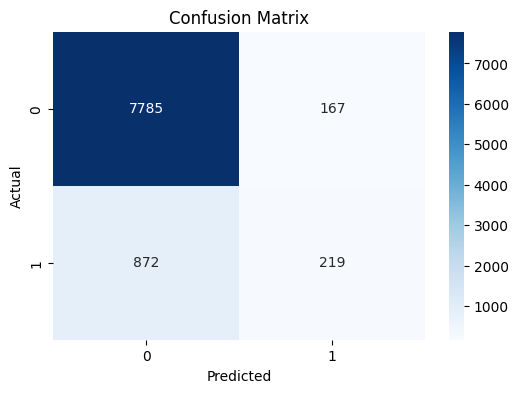

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Observation

The confusion matrix shows the number of correct and incorrect predictions. The diagonal values represent correctly classified customers, while off-diagonal values indicate misclassifications.

## Feature Importance Analysis

In [31]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance['Absolute_Coefficient'] = abs(importance['Coefficient'])

importance = importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
6,housing,-1.090091,1.090091
8,contact,-0.748320,0.748320
7,loan,-0.400532,0.400532
15,poutcome,-0.272861,0.272861
12,campaign,-0.159576,0.159576
2,marital,-0.157941,0.157941
3,education,0.093738,0.093738
4,default,-0.040659,0.040659
14,previous,0.034919,0.034919
0,age,-0.017773,0.017773


## Observation

Features with larger coefficient magnitudes have a stronger influence on loan acceptance prediction. These variables play a significant role in determining customer responses.

## Top Influential Features Visualization

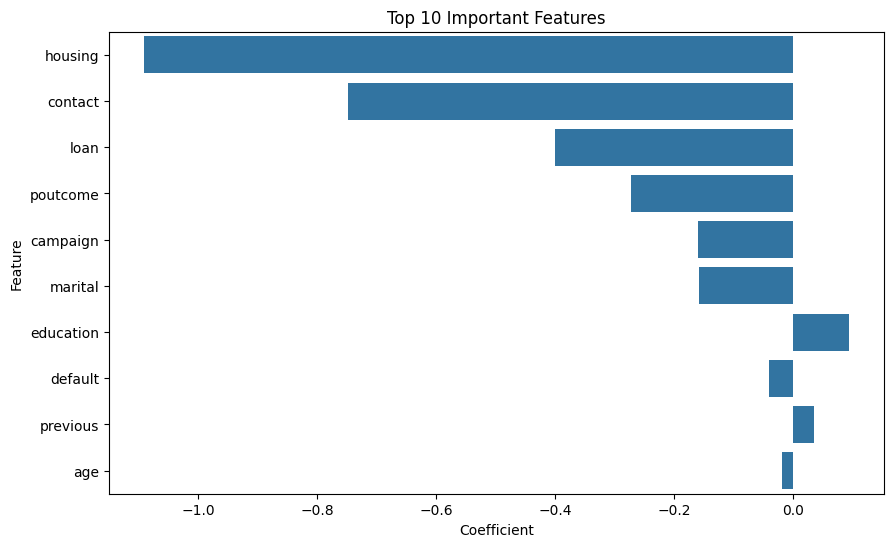

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Coefficient',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

## Observation

The chart highlights the most influential customer attributes affecting personal loan acceptance. Understanding these factors can help banks improve marketing strategies.

## Business insights

## Observation

Most customers did not accept the personal loan offer.

Customer demographics and financial characteristics influence loan acceptance.

Certain customer groups are more responsive to marketing campaigns.

Machine learning can help banks identify potential customers more efficiently.

Targeted marketing can reduce campaign costs and improve conversion rates.

## Conclusion

This project successfully developed a Personal Loan Acceptance Prediction system using the Bank Marketing Dataset and Logistic Regression. The dataset was explored, visualized, and preprocessed through encoding techniques before model training. The model achieved an accuracy of 88.51% on unseen test data. Evaluation through a confusion matrix and classification report showed excellent performance for predicting non-subscribers, while performance for predicting subscribers was comparatively lower due to class imbalance. Overall, the project demonstrates how machine learning can support banks in identifying potential customers and improving the effectiveness of loan marketing campaigns.